In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from pathlib import Path
from PIL import Image
from tqdm import tqdm
from scipy.ndimage import generic_filter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

# **Визуализация данных**

Для начала давайте посмотрим, с какими данными мы работаем.

In [2]:
df = pd.read_csv('data/labels.csv')

In [3]:
print(f"Размер датасета")
print(f"Объектов:  {len(df)}")
print(f"Признаков: {len(df.columns)}")
print(f"\nКолонки: {df.columns.tolist()}")
print(f"\nТипы данных:\n{df.dtypes}")

Размер датасета
Объектов:  172950
Признаков: 2

Колонки: ['image', 'label']

Типы данных:
image    str
label    str
dtype: object


Как видно, я оставил далеко не все ~811000 объектов исходного датасета, а только нужные для нашей задачи - те, у которых есть лейблы.

In [4]:
print(f"Пропуски:\n{df.isnull().sum()}")
print(f"\nДубликатов по image: {df['image'].duplicated().sum()}")
print(f"Дубликатов по всей строке: {df.duplicated().sum()}")

# Проверяем что все файлы реально существуют
img_dir = Path('data/images_original')
missing_files = [f for f in df['image'] if not (img_dir / f).exists()]
print(f"\nОтсутствующих файлов: {len(missing_files)}")

# Проверяем странные значения в label
known_classes = {'none', 'Edge-Ring', 'Edge-Loc', 'Center', 'Loc', 'Scratch', 'Random', 'Donut', 'Near-full'}
unknown = df[~df['label'].isin(known_classes)]
print(f"Неизвестных лейблов: {len(unknown)}")

Пропуски:
image    0
label    0
dtype: int64

Дубликатов по image: 0
Дубликатов по всей строке: 0

Отсутствующих файлов: 0
Неизвестных лейблов: 0


Действительно, все объекты удовлетворяют критериям отбора. К тому же нет дубликатов.

label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

Макс/мин соотношение: 989.5x


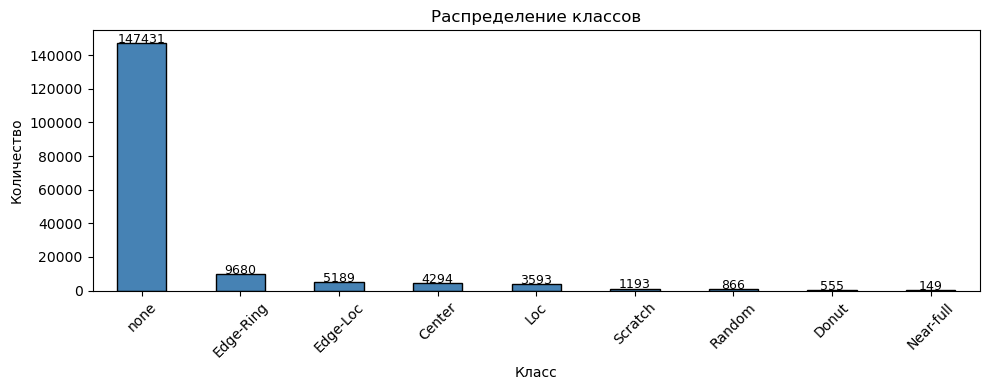

In [5]:
counts = df['label'].value_counts()
print(counts)
print(f"\nМакс/мин соотношение: {counts.max() / counts.min():.1f}x")

fig, ax = plt.subplots(figsize=(10, 4))
counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Распределение классов')
ax.set_xlabel('Класс')
ax.set_ylabel('Количество')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(counts):
    ax.text(i, v + 30, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

Наблюдается огромный дизбаланс классов, с которым я и буду бороться в блоке предобработки.

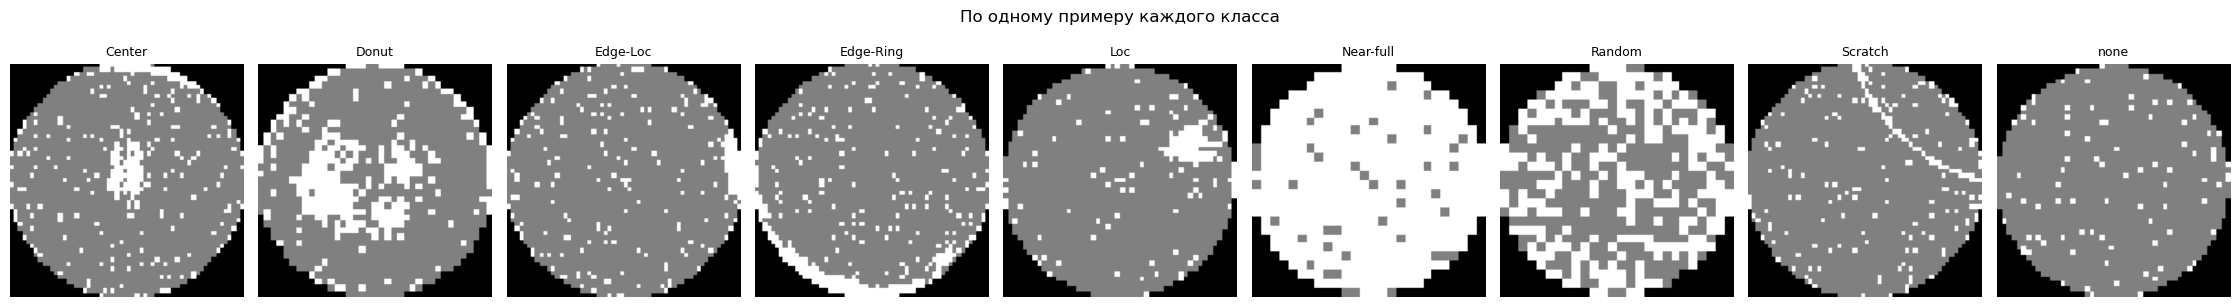

In [6]:
classes = df['label'].unique()
n = len(classes)
fig, axes = plt.subplots(1, n, figsize=(2.5 * n, 3))

for ax, cls in zip(axes, sorted(classes)):
    sample = df[df['label'] == cls].iloc[0]
    img = Image.open(img_dir / sample['image']).convert('L')
    ax.imshow(np.array(img), cmap='gray', vmin=0, vmax=254)
    ax.set_title(cls, fontsize=9)
    ax.axis('off')

plt.suptitle('По одному примеру каждого класса', y=1.02)
plt.tight_layout()
plt.show()

Можно посмотреть на примеры неисправностей пластин, которые собраны под разными лейблами.

---

# **Блок предобработки**

0 этап: downsamling для баланса классов.
Логично начать с этого этапа, чтобы в дальнейшей предобработе участвовало меньше объектов. Как и в статье, оставляю 6000 объектов без дефектов, т.е. класса none.

In [7]:
df = pd.read_csv('data/labels.csv')
print("До даунсэмплинга:")
print(df['label'].value_counts())

# Даунсэмплинг: в статье обрезают класс none, оставляя всего 6000 объектов, принадлежищих к нему.
df_none = df[df['label'] == 'none'].sample(n=6000, random_state=42)
df_rest = df[df['label'] != 'none']

df_balanced = pd.concat([df_none, df_rest]).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nПосле даунсэмплинга:")
print(df_balanced['label'].value_counts())
print(f"\nИтого: {len(df_balanced)} картинок")

df_balanced.to_csv('data/labels_balanced.csv', index=False)

До даунсэмплинга:
label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

После даунсэмплинга:
label
Edge-Ring    9680
none         6000
Edge-Loc     5189
Center       4294
Loc          3593
Scratch      1193
Random        866
Donut         555
Near-full     149
Name: count, dtype: int64

Итого: 31519 картинок


1 этап: окно 3 на 3 с выбором дефектных пикселей.

count_defect_neighbors - считает число дефектных пикселей в окне

apply_conditional_filling - поэтапно для каждолго пикселя:
1) вырезает окно 3х3 вокруг него
2) передает получившиеся 9 пикселей как плоский массив в count_defect_neighbors
3) записывает результат функции в соответствующий пиксель выходного массива

In [8]:
def count_defect_neighbors(window):
    center = window[4]
    return np.sum(window > 1.5) - (1 if center > 1.5 else 0)

def apply_conditional_filling(img_array, threshold=4):
    wmap = np.round(img_array / 127).astype(np.float64)
    neighbor_counts = generic_filter(wmap, count_defect_neighbors, size=3, mode='constant', cval=0)
    result = wmap.copy()
    result[(wmap > 1.5) & (neighbor_counts < threshold)] = 1
    return (result * 127).astype(np.uint8)

In [9]:
src_dir = Path('data/images_original')
dst_dir = Path('data/images_step1')
dst_dir.mkdir(exist_ok=True)

for fname in tqdm(df_balanced['image']):
    img_array = np.array(Image.open(src_dir / fname).convert('L'))
    processed = apply_conditional_filling(img_array)
    Image.fromarray(processed).save(dst_dir / fname)

print("Готово!")

100%|██████████| 31519/31519 [15:37<00:00, 33.62it/s]

Готово!


2 этап: маскирование. Оставляем только черные и белые пиксели. Таким образом создаем ground truth для модели сегментации.

In [10]:
mask_dir = Path('data/masks')
mask_dir.mkdir(exist_ok=True)

for fname in tqdm(df_balanced['image']):
    img = np.array(Image.open(Path('data/images_step1') / fname).convert('L'))
    mask = (img == 254).astype(np.uint8) * 255
    Image.fromarray(mask).save(mask_dir / fname)

100%|██████████| 31519/31519 [00:10<00:00, 2888.44it/s]


Давайте посмотрим на результаты работы каждого из блоков предобработки.

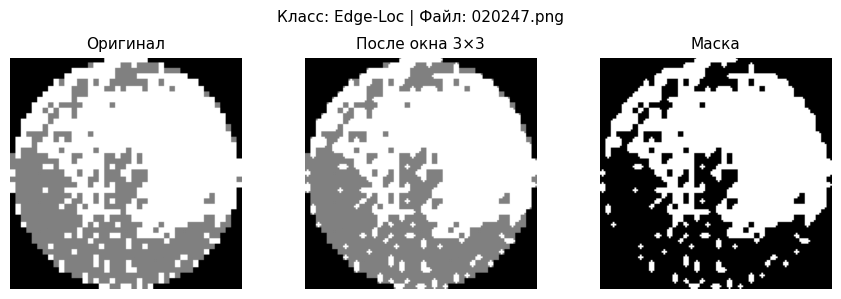

In [11]:
sample = df_balanced.sample(n=1, random_state=42).iloc[0]
fname = sample['image']
label = sample['label']

dirs = {
    'Оригинал':       Path('data/images_original'),
    'После окна 3×3': Path('data/images_step1'),
    'Маска':          Path('data/masks'),
}

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, (title, img_dir) in zip(axes, dirs.items()):
    img = np.array(Image.open(img_dir / fname).convert('L'))
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.suptitle(f'Класс: {label} | Файл: {fname}', fontsize=11)
plt.tight_layout()
plt.show()


# **Сегментационная модель**

Теперь реализую сегментационную модель прямо как в статье. Её задача - обнаруживать и выделять дефекты на карте пластины.

Сначала вспомогательная функция для отрисовки графика лосса во время обучения.

In [12]:
def plot_loss(train_history, val_history, best_epoch, title):
    epochs = range(1, len(train_history) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, train_history, marker='o', label='Train loss')
    plt.plot(epochs, val_history,   marker='o', label='Val loss')
    plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Лучшая эпоха ({best_epoch})')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('CrossEntropyLoss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Далее определю функцию для обучения сегментационной модели.

In [13]:
def train_segmentation(train_loader, val_loader, save_path, epochs=20, patience=5):
    """Обучение сегментационной модели с early stopping по val loss."""
    model = SegmentationModel().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    best_loss = float('inf')
    best_epoch = 1
    patience_counter = 0
    train_loss_history = []
    val_loss_history = []

    for epoch in range(epochs):
        # Train
        model.train()
        epoch_loss = 0
        for imgs, masks in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            imgs  = imgs.to(device)
            masks = masks.to(device)
            preds = model(imgs)
            loss  = criterion(preds, masks)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_train_loss = epoch_loss / len(train_loader)
        train_loss_history.append(avg_train_loss)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs  = imgs.to(device)
                masks = masks.to(device)
                preds = model(imgs)
                loss  = criterion(preds, masks)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)
        val_loss_history.append(avg_val_loss)

        print(f"Epoch {epoch+1}: train_loss = {avg_train_loss:.4f}  val_loss = {avg_val_loss:.4f}")

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_epoch = epoch + 1
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping на эпохе {epoch+1}, лучшая эпоха: {best_epoch}")
                break

    print(f"\nЛучшая эпоха: {best_epoch}, val_loss = {best_loss:.4f}")
    return model, train_loss_history, val_loss_history, best_epoch

Теперь сам класс модели.

In [14]:
class SegmentationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=1, padding=1), nn.ReLU(), nn.MaxPool2d(2, stride=2),  
            nn.Conv2d(32, 64, 3, stride=1, padding=1), nn.ReLU(), nn.MaxPool2d(2, stride=2),
            nn.Conv2d(64, 128, 3, stride=1, padding=1), nn.ReLU(), nn.MaxPool2d(2, stride=2)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1), nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

Создаю класс датасета для обучения.

In [15]:
class SegmentationDataset(Dataset):
    def __init__(self, csv_path, img_dir, mask_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = Path(img_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fname = self.df.iloc[idx]['image']
        img = Image.open(self.img_dir / fname).convert('L')
        mask = Image.open(self.mask_dir / fname).convert('L')
        if self.transform:
            img = self.transform(img)
            mask = self.transform(mask)
        return img, mask

Дальше идёт само обучение.

In [16]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Устройство: {device}")

Устройство: mps


In [17]:
transform = transforms.ToTensor()

dataset = SegmentationDataset(
    'data/labels_balanced.csv',
    'data/images_step1',
    'data/masks',
    transform=transform
)

train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=0)

Epoch 1/20: 100%|██████████| 788/788 [00:41<00:00, 19.18it/s]


Epoch 1: train_loss = 0.1158  val_loss = 0.0585


Epoch 2/20: 100%|██████████| 788/788 [00:40<00:00, 19.52it/s]


Epoch 2: train_loss = 0.0471  val_loss = 0.0398


Epoch 3/20: 100%|██████████| 788/788 [00:50<00:00, 15.64it/s]


...

Epoch 18: train_loss = 0.0085  val_loss = 0.0086


Epoch 19/20: 100%|██████████| 788/788 [00:51<00:00, 15.42it/s]


Epoch 19: train_loss = 0.0083  val_loss = 0.0086


Epoch 20/20: 100%|██████████| 788/788 [00:51<00:00, 15.24it/s]


Epoch 20: train_loss = 0.0078  val_loss = 0.0076

Лучшая эпоха: 20, val_loss = 0.0076


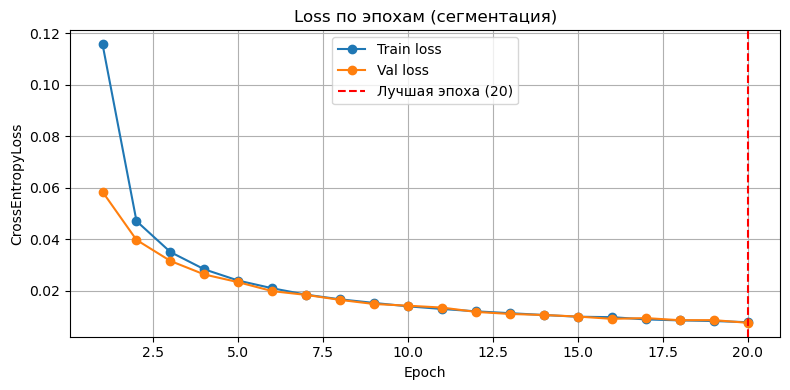

In [18]:
model, train_hist_seg, val_hist_seg, best_epoch_seg = train_segmentation(
    train_loader, val_loader,
    save_path='data/segmentation_best.pth'
)

plot_loss(train_hist_seg, val_hist_seg, best_epoch_seg, 'Loss по эпохам (сегментация)')

Далее выведу метрики, использую такие же, как в оригинальной статье. 

In [19]:
def mae_score(pred, target):
    """Средняя абсолютная ошибка между предсказанной и истинной маской."""
    return torch.abs(pred - target).mean()

def rmse_score(pred, target):
    """Среднеквадратичная ошибка между предсказанной и истинной маской."""
    return torch.sqrt(((pred - target) ** 2).mean())

def snr_score(pred, target):
    """Отношение сигнала к шуму."""
    signal = (target ** 2).sum()
    noise  = ((pred - target) ** 2).sum()
    return 10 * torch.log10(signal / (noise + 1e-8))

def dice_score(pred, target, threshold=0.5):
    """Dice Index — мера перекрытия предсказанной и истинной маски."""
    pred         = (pred > threshold).float()
    intersection = (pred * target).sum()
    return (2 * intersection) / (pred.sum() + target.sum() + 1e-8)

def iou_score(pred, target, threshold=0.5):
    """Intersection over Union — отношение пересечения к объединению масок."""
    pred         = (pred > threshold).float()
    intersection = (pred * target).sum()
    union        = pred.sum() + target.sum() - intersection
    return intersection / (union + 1e-8)

In [20]:
def evaluate_segmentation(model, loader, save_path):
    """Метрики сегментационной модели на переданном загрузчике."""
    model.load_state_dict(torch.load(save_path, map_location=device))
    model.eval()

    total_dice, total_iou, total_mae, total_rmse, total_snr = 0, 0, 0, 0, 0

    with torch.no_grad():
        for imgs, masks in tqdm(loader):
            imgs  = imgs.to(device)
            masks = masks.to(device)
            preds = model(imgs)
            total_dice += dice_score(preds, masks).item()
            total_iou  += iou_score(preds, masks).item()
            total_mae  += mae_score(preds, masks).item()
            total_rmse += rmse_score(preds, masks).item()
            total_snr  += snr_score(preds, masks).item()

    n = len(loader)
    print(f"MAE:  {total_mae  / n:.4f}")
    print(f"RMSE: {total_rmse / n:.4f}")
    print(f"SNR:  {total_snr  / n:.4f}")
    print(f"Dice: {total_dice / n:.4f}")
    print(f"IoU:  {total_iou  / n:.4f}")

In [21]:
evaluate_segmentation(model, val_loader, 'data/segmentation_best.pth')

100%|██████████| 197/197 [00:07<00:00, 28.10it/s]

MAE:  0.0044
RMSE: 0.0450
SNR:  17.7417
Dice: 0.9879
IoU:  0.9762


Выводы по метрикам: MAE чуть хуже, чем в оригинальной статье, RMSE при этом чуть лучше. Но я бы сказал, что они примерно такие же, и в целом значения достаточно маленькие. То есть средняя ошибка на пиксель и стандартное отклонение околонулевые.

Теперь о метриках для изображений.

SNR - Signal to Noise ratio, то есть отношение сигнала к шуму. Намного лучше, чем в статье, хотя я убрал из блока предобработки автоэнкодер(ибо неясно, зачем он там нужен).

Dice Index и Intersection over Union - очень похожи по своей сути метрики, и значения у них получились очень близкими и очень высокими. Это означает, что предсказанная маска совпадает с исходной очень и очень хорошо. То есть модель действительно научилась выделять дефектные части пластины.

Также нужно сохранить маски, полученные сегментационной моделью, для работы с классификатором.

In [22]:
pred_mask_dir = Path('data/masks_predicted')
pred_mask_dir.mkdir(exist_ok=True)

full_dataset = SegmentationDataset(
    'data/labels_balanced.csv',
    'data/images_step1',
    'data/masks',
    transform=transform
)
full_loader = DataLoader(full_dataset, batch_size=32, shuffle=False, num_workers=0)

df_balanced = pd.read_csv('data/labels_balanced.csv')
idx = 0

with torch.no_grad():
    for imgs, masks in tqdm(full_loader):
        imgs = imgs.to(device)
        preds = model(imgs)
        preds_bin = (preds > 0.5).squeeze(1).cpu().numpy().astype(np.uint8) * 255

        for i in range(len(preds_bin)):
            fname = df_balanced.iloc[idx]['image']
            Image.fromarray(preds_bin[i]).save(pred_mask_dir / fname)
            idx += 1

100%|██████████| 985/985 [00:41<00:00, 23.95it/s]


Теперь давайте посмотрим на результаты обучения модели. Выведем по 3 примера топ-3 по IoU с конца и с начала, для этих примеров выведем оригинал, ту маску, которую мы получили после предобработки, и предсказанную маску соответственно. Также выведем распределение IoU по классам.

Считаем IoU: 100%|██████████| 985/985 [00:43<00:00, 22.65it/s]


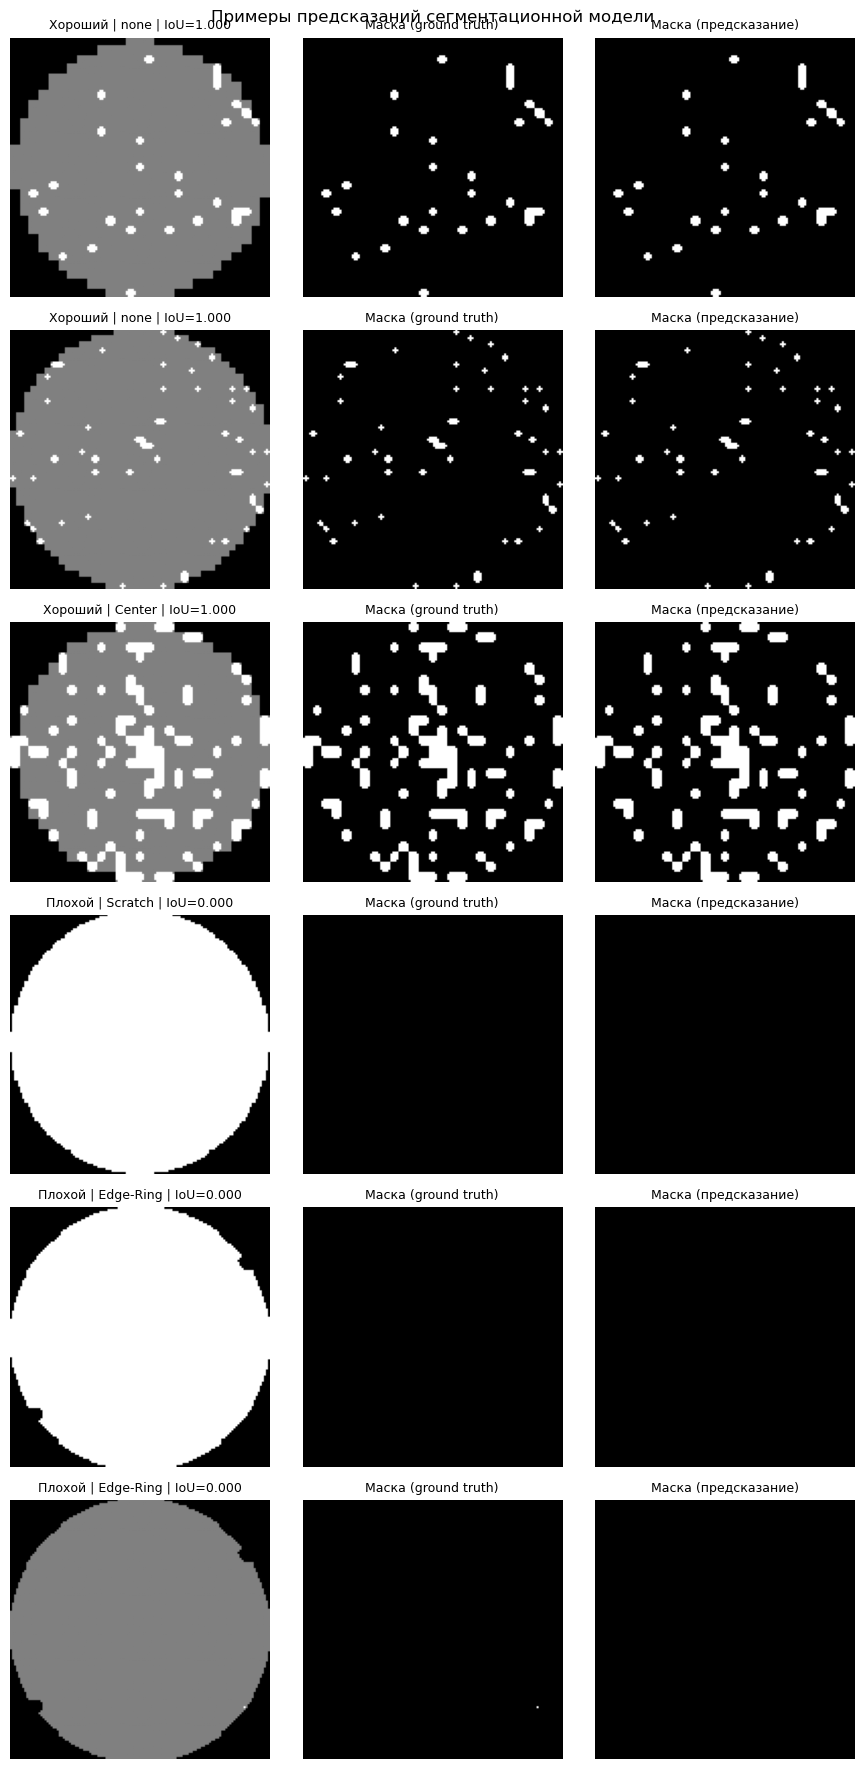

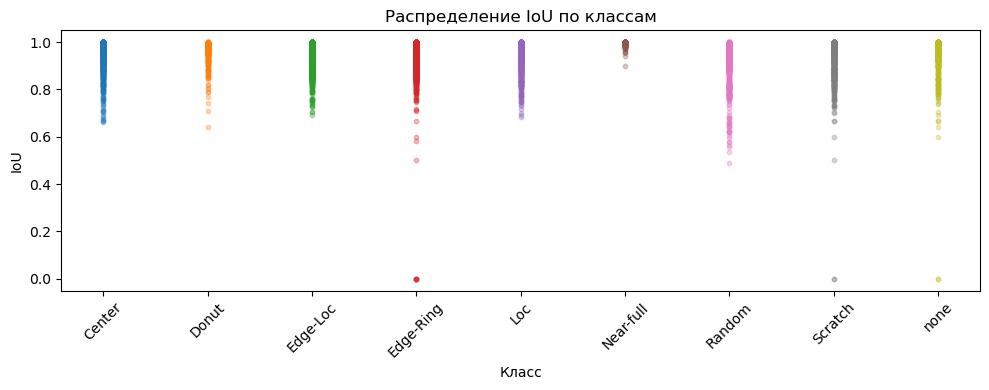

In [23]:
def show_segmentation_examples(df):
    model.eval()
    sample_results = []

    dataset_viz = SegmentationDataset(
        'data/labels_balanced.csv', 'data/images_step1', 'data/masks', transform=transform
    )
    loader_viz = DataLoader(dataset_viz, batch_size=32, shuffle=False, num_workers=0)

    idx = 0
    with torch.no_grad():
        for imgs, masks in tqdm(loader_viz, desc='Считаем IoU'):
            imgs  = imgs.to(device)
            masks = masks.to(device)
            preds = model(imgs)
            for i in range(len(imgs)):
                iou = iou_score(preds[i:i+1], masks[i:i+1]).item()
                sample_results.append({
                    'fname': df.iloc[idx]['image'],
                    'label': df.iloc[idx]['label'],
                    'iou':   iou
                })
                idx += 1

    results_df = pd.DataFrame(sample_results)

    # Топ-3 лучших и топ-3 худших
    best  = results_df.nlargest(3, 'iou')
    worst = results_df.nsmallest(3, 'iou')
    examples = pd.concat([best, worst]).reset_index(drop=True)
    titles   = ['Хороший'] * 3 + ['Плохой'] * 3

    fig, axes = plt.subplots(6, 3, figsize=(9, 18))
    dirs = {
        'Оригинал':             Path('data/images_step1'),
        'Маска (ground truth)': Path('data/masks'),
        'Маска (предсказание)': Path('data/masks_predicted'),
    }
    for row_idx, (_, row) in enumerate(examples.iterrows()):
        for col_idx, (title, img_dir) in enumerate(dirs.items()):
            img = np.array(Image.open(img_dir / row['fname']).convert('L'))
            axes[row_idx, col_idx].imshow(img, cmap='gray')
            axes[row_idx, col_idx].axis('off')
            if col_idx == 0:
                axes[row_idx, col_idx].set_title(
                    f"{titles[row_idx]} | {row['label']} | IoU={row['iou']:.3f}", fontsize=9
                )
            else:
                axes[row_idx, col_idx].set_title(title, fontsize=9)

    plt.suptitle('Примеры предсказаний сегментационной модели', fontsize=12)
    plt.tight_layout()
    plt.show()

    # Распределение IoU по классам
    fig, ax = plt.subplots(figsize=(10, 4))
    for cls in sorted(results_df['label'].unique()):
        subset = results_df[results_df['label'] == cls]['iou']
        ax.scatter([cls] * len(subset), subset, alpha=0.3, s=10)
    ax.set_xlabel('Класс')
    ax.set_ylabel('IoU')
    ax.set_title('Распределение IoU по классам')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


show_segmentation_examples(df_balanced)

По примерам хороших и плохих предсказаний сегментационной модели видно, что какие-то карты вообще не получилось восстановить. Тем не менее, это скорее выбросы в самих данных. Если посмотреть на распределение IoU по классам, то видно, что есть 4 класса, которые модель хуже всего сегментирует. Это должно отразиться и на результатах классификации.

# **Классификационная модель**

Теперь я реализую классификационную модель, которая определяет класс дефекта(или его отсутствие). Сначала идут энкодеры(свертки), которые вытаскивают признаки из предсказанных карт пластин. Затем полносвязные слои(FC), которые и классифицируют карты по построенным признаковым описаниям картинок.

Сначала я реализую вспомогательные функции для обучения модели и вывода метрик на нужном датасете.

In [24]:
def train_classifier(train_loader, val_loader, class_weights, save_path, epochs=20, patience=5):
    model = ClassificationModel().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    best_loss = float('inf')
    best_epoch = 1
    train_loss_history = []
    val_loss_history = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            inputs = inputs.to(device)
            labels = labels.to(device)
            preds  = model(inputs)
            loss   = criterion(preds, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_train_loss = epoch_loss / len(train_loader)
        train_loss_history.append(avg_train_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                preds  = model(inputs)
                loss   = criterion(preds, labels)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)
        val_loss_history.append(avg_val_loss)

        print(f"Epoch {epoch+1}: train_loss = {avg_train_loss:.4f}  val_loss = {avg_val_loss:.4f}")

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_epoch = epoch + 1
            torch.save(model.state_dict(), save_path)  # лучшая по val loss

    # Сохраняем финальную переобученную модель отдельно
    overfit_path = save_path.replace('.pth', '_overfit.pth')
    torch.save(model.state_dict(), overfit_path)

    print(f"\nЛучшая эпоха: {best_epoch}, val_loss = {best_loss:.4f}")
    return model, train_loss_history, val_loss_history, best_epoch
    
def evaluate_classifier(model, loader, classes_list, save_path, title_suffix=''):
    model.load_state_dict(torch.load(save_path, map_location=device))
    model.eval()

    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in tqdm(loader):
            inputs = inputs.to(device)
            preds  = model(inputs)
            probs  = F.softmax(preds, dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.argmax(dim=1).cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)

    print(f"Accuracy:  {accuracy_score(all_labels, all_preds):.4f}  (статья: 0.9705)")
    print(f"Precision: {precision_score(all_labels, all_preds, average='weighted'):.4f}  (статья: 0.9678)")
    print(f"Recall:    {recall_score(all_labels, all_preds, average='weighted'):.4f}  (статья: 0.9705)")
    print(f"F1:        {f1_score(all_labels, all_preds, average='weighted'):.4f}  (статья: 0.9676)")

    # ROC AUC
    y_bin = label_binarize(all_labels, classes=range(len(classes_list)))
    fig, ax = plt.subplots(figsize=(10, 7))
    for i, cls in enumerate(classes_list):
        fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
        ax.plot(fpr, tpr, label=f'{cls} (AUC = {auc(fpr, tpr):.2f})')
    ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC AUC по классам {title_suffix}')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes_list)
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix {title_suffix}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return all_labels, all_preds, all_probs

Определим класс модели в соответствии со статьёй.

In [25]:
class ClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1), nn.ReLU(), nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), nn.ReLU(), nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), nn.ReLU(), nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(256, 9)
        )

    def forward(self, x):
        return self.classifier(self.encoder(x))

Теперь напишем класс датасета для обучения классификационной модели.

In [26]:
class ClassificationDatasetImg(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.classes = sorted(self.df['label'].unique())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.img_dir / row['image']).convert('L')
        label = self.class_to_idx[row['label']]
        if self.transform:
            img = self.transform(img)
        return img, label

Даже учитываю downsampling, у нас все равно сильный дизбаланс классов(например, 6000 none vs 149 Near-full). Поэтому я думаю, что хорошей идеей будет использовать взвешенную функцию потерь, в нашем случае - взвешенную кросс-энтропию.

In [27]:
df_balanced  = pd.read_csv('data/labels_balanced.csv')
classes_list = sorted(df_balanced['label'].unique())
class_to_idx = {c: i for i, c in enumerate(classes_list)}
labels_all   = df_balanced['label'].map(class_to_idx).values

class_weights_all = torch.tensor(
    compute_class_weight('balanced', classes=np.arange(len(classes_list)), y=labels_all),
    dtype=torch.float
).to(device)

In [28]:
dataset_random = ClassificationDatasetImg(
    'data/labels_balanced.csv', 'data/images_step1', transform=transforms.ToTensor()
)

train_size_r = int(0.7 * len(dataset_random))
val_size_r   = int(0.15 * len(dataset_random))
test_size_r  = len(dataset_random) - train_size_r - val_size_r

train_r, val_r, test_r = random_split(
    dataset_random, 
    [train_size_r, val_size_r, test_size_r],
    generator=torch.Generator().manual_seed(42) 
)

train_loader_r = DataLoader(train_r, batch_size=16, shuffle=True,  num_workers=0)
val_loader_r   = DataLoader(val_r,   batch_size=16, shuffle=False, num_workers=0)
test_loader_r  = DataLoader(test_r,  batch_size=16, shuffle=False, num_workers=0)

Сначала выберу baseline-модель - она будет предсказывать самый популярный класс, то есть Edge-ring. Тем не менее, код напишу в общем виде, чтобы можно было переиспользовать.

In [29]:
majority_class     = df_balanced['label'].value_counts().idxmax()
majority_class_idx = class_to_idx[majority_class]
baseline_preds     = np.full(test_size_r, majority_class_idx)

test_labels_r = np.array([dataset_random[i][1] for i in test_r.indices])

print(f"Baseline (majority class = '{majority_class}') on TEST SET:")
print(f"Accuracy:  {accuracy_score(test_labels_r, baseline_preds):.4f}")
print(f"Precision: {precision_score(test_labels_r, baseline_preds, average='weighted', zero_division=0):.4f}")
print(f"Recall:    {recall_score(test_labels_r, baseline_preds, average='weighted', zero_division=0):.4f}")
print(f"F1:        {f1_score(test_labels_r, baseline_preds, average='weighted', zero_division=0):.4f}")

Baseline (majority class = 'Edge-Ring') on TEST SET:
Accuracy:  0.2986
Precision: 0.0892
Recall:    0.2986
F1:        0.1373


Очень плохие метрики, но есть, с чем сравнивать.

Сам процесс обучения.

Epoch 1/20: 100%|██████████| 1379/1379 [00:49<00:00, 27.89it/s]


Epoch 1: train_loss = 1.1388  val_loss = 0.6332


Epoch 2/20: 100%|██████████| 1379/1379 [00:44<00:00, 31.02it/s]


Epoch 2: train_loss = 0.7144  val_loss = 0.5427


Epoch 3/20: 100%|██████████| 1379/1379 [00:44<00:00, 30.73it/s]


...

Epoch 18: train_loss = 0.0869  val_loss = 0.9510


Epoch 19/20: 100%|██████████| 1379/1379 [00:45<00:00, 30.33it/s]


Epoch 19: train_loss = 0.0998  val_loss = 0.7385


Epoch 20/20: 100%|██████████| 1379/1379 [00:45<00:00, 30.19it/s]


Epoch 20: train_loss = 0.0927  val_loss = 0.7452

Лучшая эпоха: 4, val_loss = 0.4035


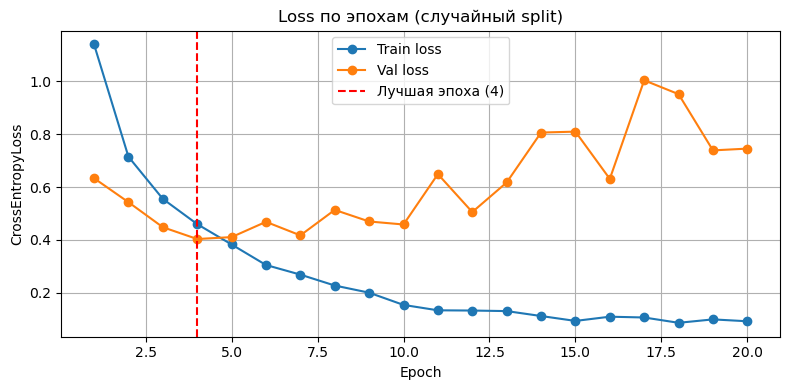

In [30]:
model_random, train_hist_r, val_hist_r, best_epoch_r = train_classifier(
    train_loader_r, val_loader_r, class_weights_all,
    save_path='data/classification_random.pth'
)
plot_loss(train_hist_r, val_hist_r, best_epoch_r, 'Loss по эпохам (случайный split)')

По графику видно сильное переобучение модели под тренировочные данные.

Теперь посмотрим на метрики на тестовом наборе.

100%|██████████| 296/296 [00:03<00:00, 89.84it/s]

Accuracy:  0.8634  (статья: 0.9705)
Precision: 0.8794  (статья: 0.9678)
Recall:    0.8634  (статья: 0.9705)
F1:        0.8680  (статья: 0.9676)


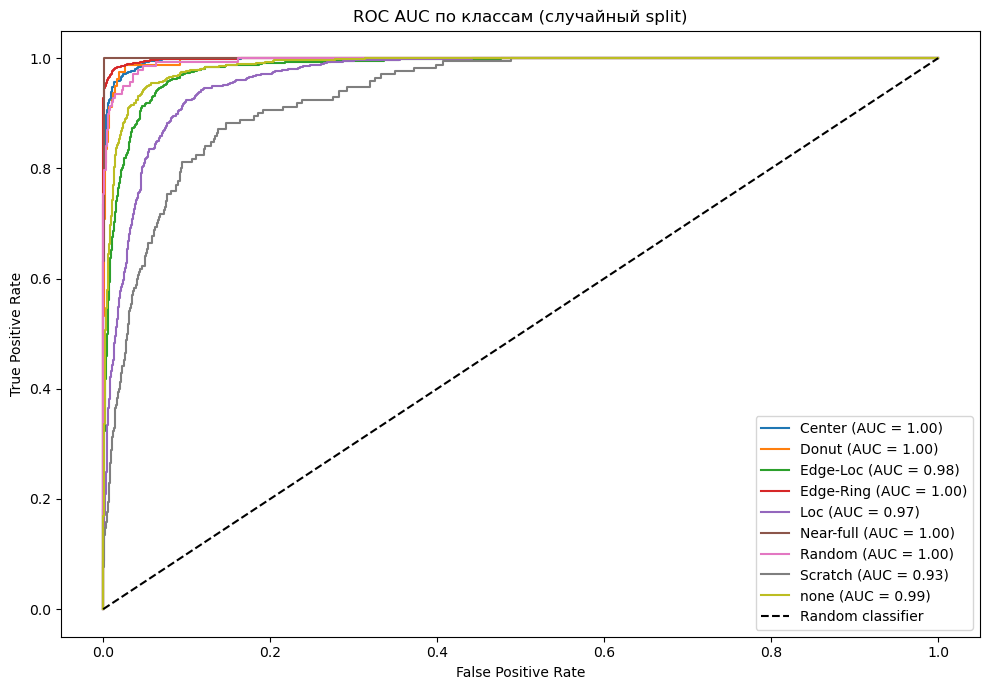

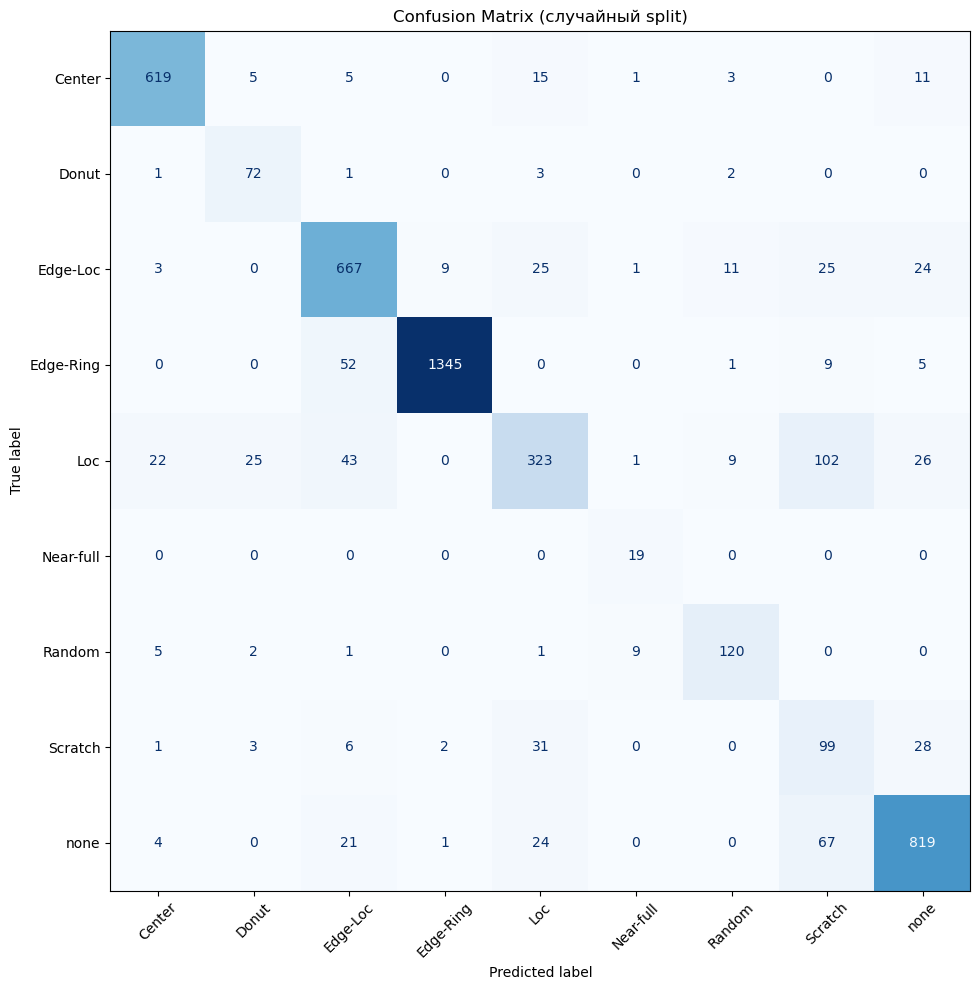

In [31]:
labels_r, preds_r, probs_r = evaluate_classifier(
    model_random, 
    test_loader_r,
    classes_list,
    save_path='data/classification_random.pth',
    title_suffix='(случайный split)'
)

Метрики получились далеко не такими высокими, как в статье. Я стал искать причину такого результата, перепробовал разные конфигурации моделей и датасетов, ничего не помогало. В итоге в самой статье я внимательно посмотрел на confusion matrix и понял, что, скорее всего, они вывели метрики на всём датасете. Давайте проверим это.

100%|██████████| 1970/1970 [00:19<00:00, 100.46it/s]


Accuracy:  0.9642  (статья: 0.9705)
Precision: 0.9641  (статья: 0.9678)
Recall:    0.9642  (статья: 0.9705)
F1:        0.9641  (статья: 0.9676)


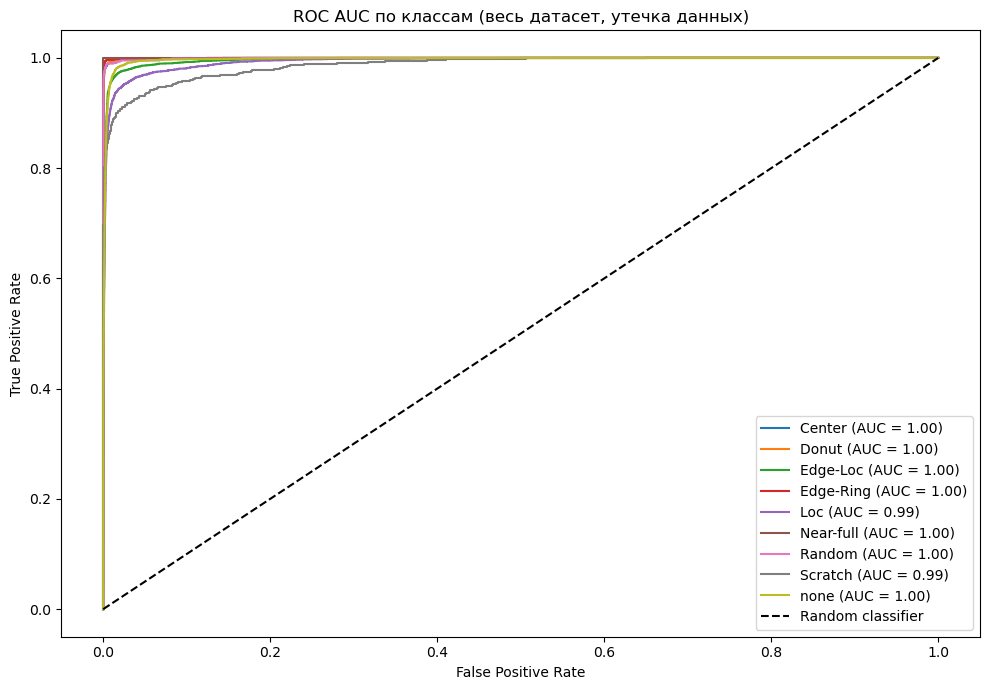

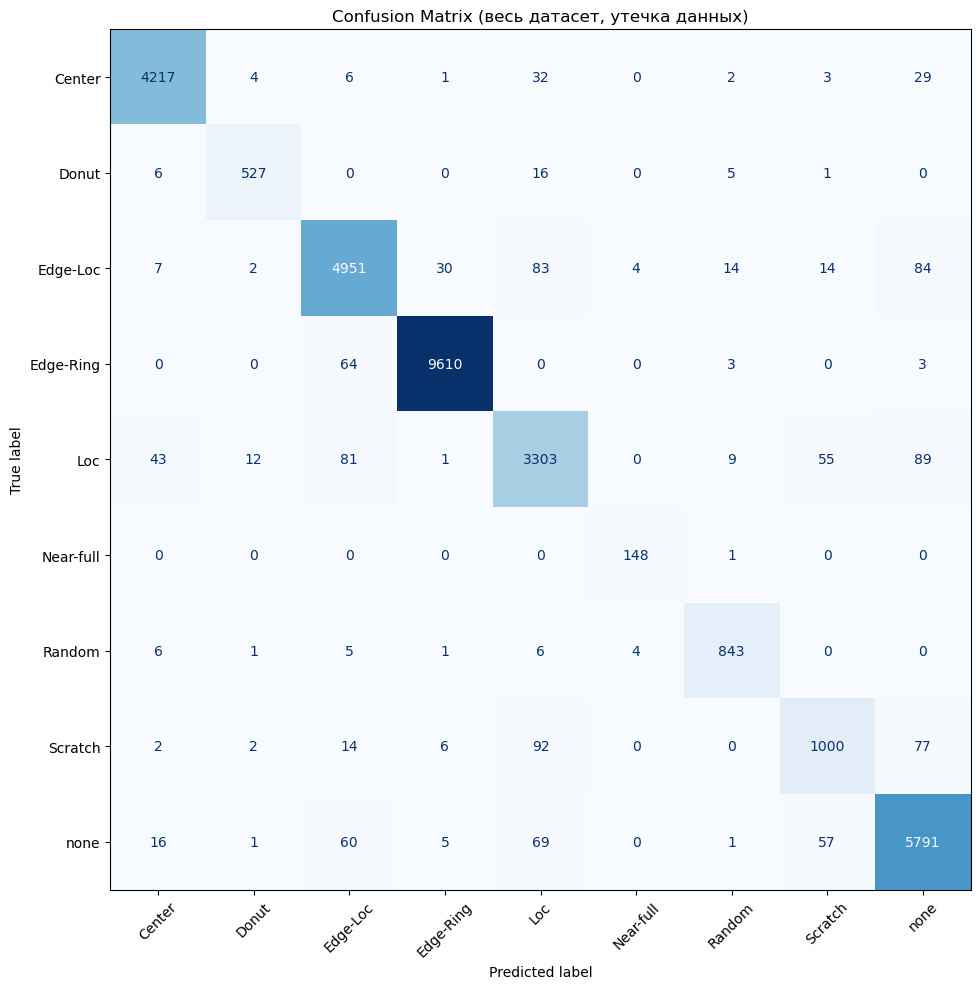

In [32]:
full_dataset = ClassificationDatasetImg(
    'data/labels_balanced.csv', 'data/images_step1', transform=transforms.ToTensor()
)
full_loader = DataLoader(full_dataset, batch_size=16, shuffle=False, num_workers=0)

labels_full, preds_full, probs_full = evaluate_classifier(
    model_random, full_loader, classes_list,
    save_path='data/classification_random_overfit.pth',
    title_suffix='(весь датасет, утечка данных)'
)

Так и есть! Метрики получились даже немного выше(совсем незначительно), чем в статье. Я считаю, что это ненадежный результат, ведь произошла утечка данных(считаем метрики на тех данных, на которых и училась модель). Так что мои значения в окрестности 0.87 отражают реальное качество модели. 

Также меня посетила идея попробовать разбиение на трейн и тест с сохранением пропорций классов(stratified split), ведь даже после downsampling'а дизбаланс классов очень сильный. Далее - обучение модели на данных, к которым я применил StratifiedShuffleSplit из sklearn.

In [33]:
train_val_idx, test_idx_s = train_test_split(
    np.arange(len(df_balanced)),
    test_size=0.15,
    stratify=labels_all,
    random_state=42
)

train_idx_s, val_idx_s = train_test_split(
    train_val_idx,
    test_size=0.1765,
    stratify=df_balanced.iloc[train_val_idx]['label'],
    random_state=42
)

df_train_s = df_balanced.iloc[train_idx_s].reset_index(drop=True)
df_val_s   = df_balanced.iloc[val_idx_s].reset_index(drop=True)
df_test_s  = df_balanced.iloc[test_idx_s].reset_index(drop=True)

df_train_s.to_csv('data/labels_train.csv', index=False)
df_val_s.to_csv('data/labels_val.csv',   index=False)
df_test_s.to_csv('data/labels_test.csv',  index=False)

print(f"Stratified split: Train={len(df_train_s)}, Val={len(df_val_s)}, Test={len(df_test_s)}")

Stratified split: Train=22062, Val=4729, Test=4728


In [34]:
train_dataset_s = ClassificationDatasetImg(
    'data/labels_train.csv', 'data/images_step1', transform=transforms.ToTensor()
)
val_dataset_s = ClassificationDatasetImg( 
    'data/labels_val.csv', 'data/images_step1', transform=transforms.ToTensor()
)
test_dataset_s = ClassificationDatasetImg(
    'data/labels_test.csv', 'data/images_step1', transform=transforms.ToTensor()
)

train_loader_s = DataLoader(train_dataset_s, batch_size=16, shuffle=True,  num_workers=0)
val_loader_s   = DataLoader(val_dataset_s,   batch_size=16, shuffle=False, num_workers=0) 
test_loader_s  = DataLoader(test_dataset_s,  batch_size=16, shuffle=False, num_workers=0)

labels_train_s  = df_train_s['label'].map(class_to_idx).values
class_weights_s = torch.tensor(
    compute_class_weight('balanced', classes=np.arange(len(classes_list)), y=labels_train_s),
    dtype=torch.float
).to(device)

Epoch 1/20: 100%|██████████| 1379/1379 [00:46<00:00, 29.81it/s]


Epoch 1: train_loss = 1.1303  val_loss = 0.7937


Epoch 2/20: 100%|██████████| 1379/1379 [00:45<00:00, 30.43it/s]


Epoch 2: train_loss = 0.7074  val_loss = 0.5224


Epoch 3/20: 100%|██████████| 1379/1379 [00:45<00:00, 30.46it/s]


...

Epoch 18: train_loss = 0.0783  val_loss = 0.8012


Epoch 19/20: 100%|██████████| 1379/1379 [00:49<00:00, 27.89it/s]


Epoch 19: train_loss = 0.0917  val_loss = 0.6951


Epoch 20/20: 100%|██████████| 1379/1379 [00:49<00:00, 27.85it/s]


Epoch 20: train_loss = 0.0693  val_loss = 1.1899

Лучшая эпоха: 5, val_loss = 0.4244


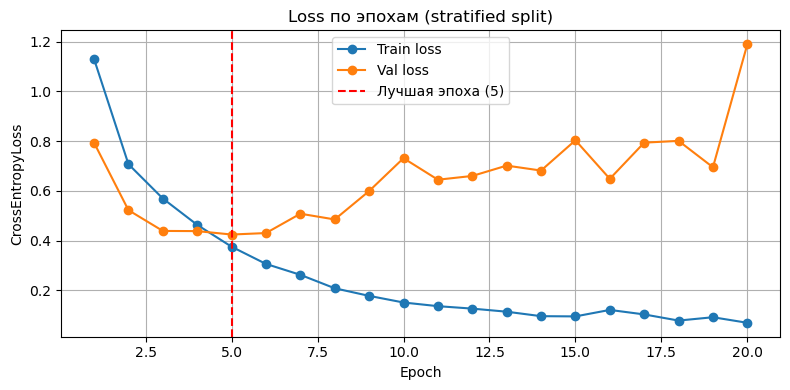

In [35]:
model_stratified, train_hist_s, val_hist_s, best_epoch_s = train_classifier(
    train_loader_s, 
    val_loader_s,
    class_weights_s,
    save_path='data/classification_stratified.pth'
)
plot_loss(train_hist_s, val_hist_s, best_epoch_s, 'Loss по эпохам (stratified split)')

То же самое переобучение под трейн.

100%|██████████| 296/296 [00:03<00:00, 85.58it/s] 

Accuracy:  0.8752  (статья: 0.9705)
Precision: 0.8824  (статья: 0.9678)
Recall:    0.8752  (статья: 0.9705)
F1:        0.8772  (статья: 0.9676)


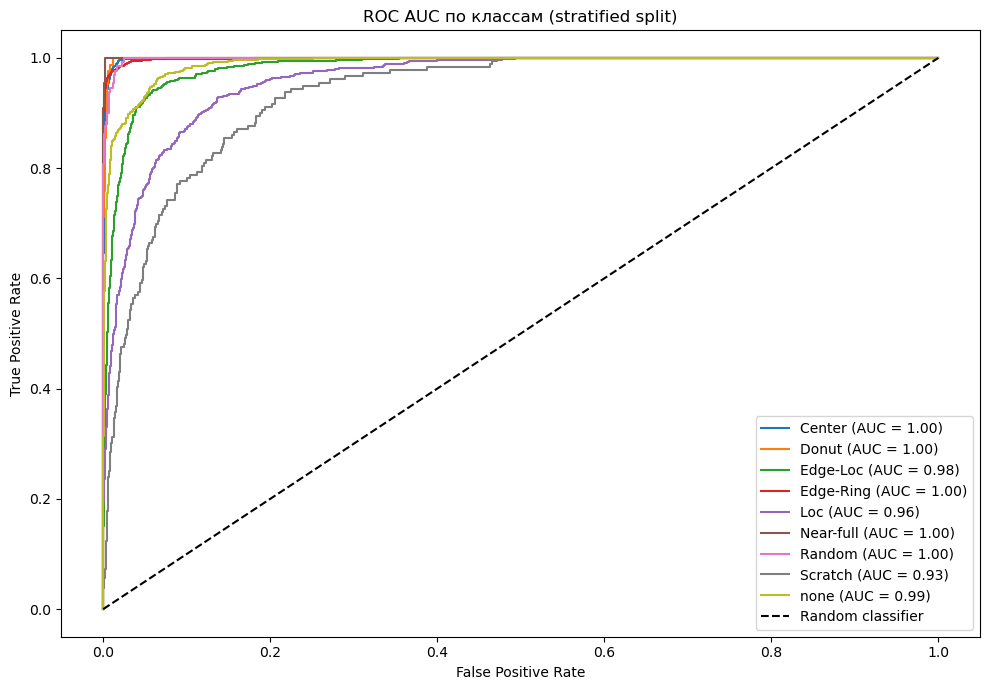

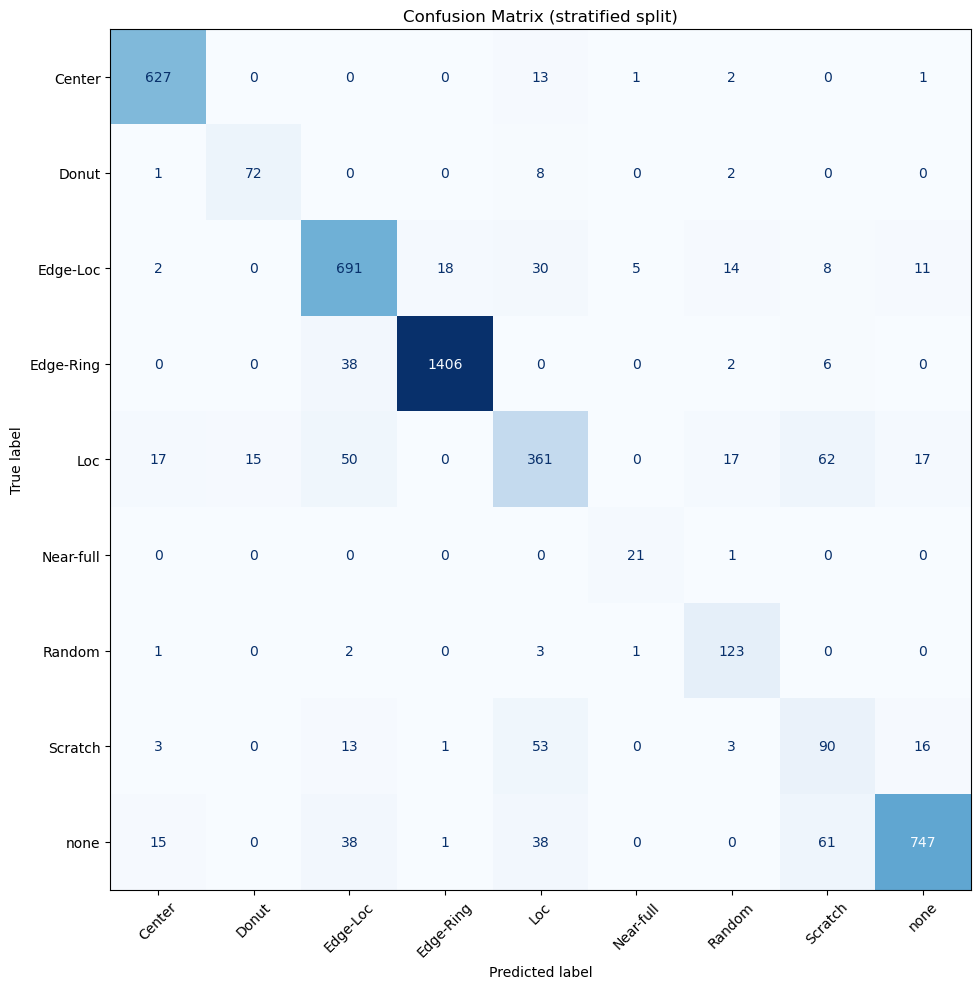

In [36]:
labels_s, preds_s, probs_s = evaluate_classifier(
    model_stratified, test_loader_s, classes_list,
    save_path='data/classification_stratified.pth',
    title_suffix='(stratified split)'
)

Как можно видеть, метрики примерно такие же. Так что действительно, те показатели, которые я получил на тесте даже для модели, обученной на нестратифицированных данных, отражают реальную способность модели классифицировать пластины по типам дефектов.

Теперь посмотрим на примеры предсказаний классификатора.

In [37]:
def show_classification_examples(df_test, model, save_path, classes_list, n=3):
    model.load_state_dict(torch.load(save_path, map_location=device))
    model.eval()

    correct_examples = []
    wrong_examples   = []

    for _, row in df_test.iterrows():
        if len(correct_examples) >= n and len(wrong_examples) >= n:
            break
        fname      = row['image']
        true_label = row['label']
        img        = transform(Image.open(Path('data/images_step1') / fname).convert('L')).unsqueeze(0).to(device)
        with torch.no_grad():
            pred_idx  = model(img).argmax(dim=1).item()
        pred_label = classes_list[pred_idx]

        entry = {'fname': fname, 'true': true_label, 'pred': pred_label}
        if true_label == pred_label and len(correct_examples) < n:
            correct_examples.append(entry)
        elif true_label != pred_label and len(wrong_examples) < n:
            wrong_examples.append(entry)

    examples = correct_examples + wrong_examples
    labels_e = ['Верно'] * len(correct_examples) + ['Ошибка'] * len(wrong_examples)

    fig, axes = plt.subplots(1, len(examples), figsize=(3 * len(examples), 3))
    for ax, entry, lbl in zip(axes, examples, labels_e):
        img = np.array(Image.open(Path('data/images_step1') / entry['fname']).convert('L'))
        ax.imshow(img, cmap='gray')
        color = 'green' if lbl == 'Верно' else 'red'
        ax.set_title(f"{lbl}\nИстина: {entry['true']}\nПред: {entry['pred']}", fontsize=8, color=color)
        ax.axis('off')

    plt.suptitle('Примеры предсказаний классификатора', fontsize=12)
    plt.tight_layout()
    plt.show()

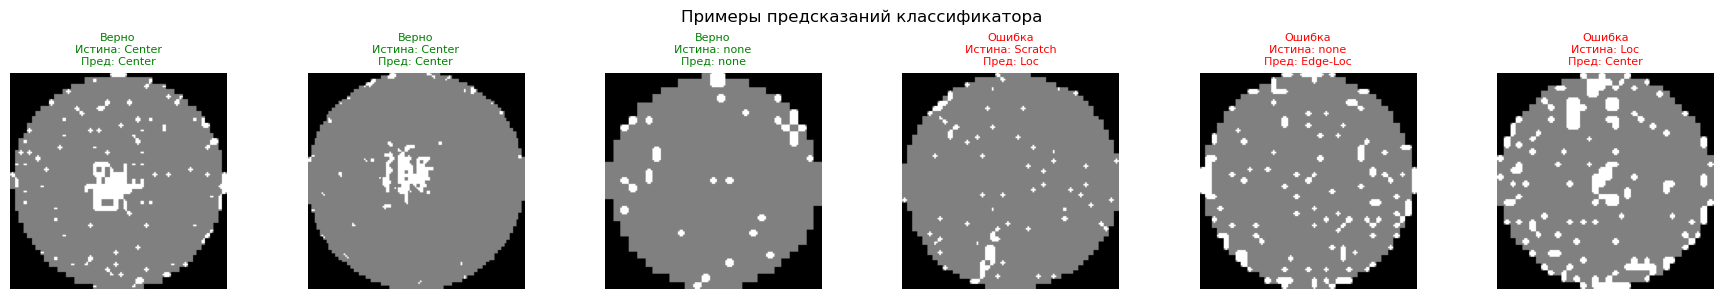

In [38]:
show_classification_examples(
    df_test_s, model_stratified,
    'data/classification_stratified.pth',
    classes_list
)

Также если посмотреть на ROC AUC, то видно, что метрики как раз хуже у тех классов, у которых IoU распределено хуже.

И давайте посмотрим на сравнительную таблицу для классификатора, обученного на данных с разными сплитами, и для результатов из статьи.

In [39]:
results_table = pd.DataFrame([
    {
        'Конфигурация':  'Baseline (majority class)',
        'Accuracy':  round(accuracy_score(test_labels_r, baseline_preds), 4),
        'Precision': round(precision_score(test_labels_r, baseline_preds, average='weighted', zero_division=0), 4),
        'Recall':    round(recall_score(test_labels_r, baseline_preds, average='weighted', zero_division=0), 4),
        'F1':        round(f1_score(test_labels_r, baseline_preds, average='weighted', zero_division=0), 4),
    },
    {
        'Конфигурация':  'Случайный split',
        'Accuracy':  round(accuracy_score(labels_r, preds_r), 4),
        'Precision': round(precision_score(labels_r, preds_r, average='weighted'), 4),
        'Recall':    round(recall_score(labels_r, preds_r, average='weighted'), 4),
        'F1':        round(f1_score(labels_r, preds_r, average='weighted'), 4),
    },
    {
        'Конфигурация':  'Stratified split',
        'Accuracy':  round(accuracy_score(labels_s, preds_s), 4),
        'Precision': round(precision_score(labels_s, preds_s, average='weighted'), 4),
        'Recall':    round(recall_score(labels_s, preds_s, average='weighted'), 4),
        'F1':        round(f1_score(labels_s, preds_s, average='weighted'), 4),
    },
    {
        'Конфигурация':  'Весь датасет (демонстрация утечки)',
        'Accuracy':  round(accuracy_score(labels_full, preds_full), 4),
        'Precision': round(precision_score(labels_full, preds_full, average='weighted'), 4),
        'Recall':    round(recall_score(labels_full, preds_full, average='weighted'), 4),
        'F1':        round(f1_score(labels_full, preds_full, average='weighted'), 4),
    },
    {
        'Конфигурация':  'Статья (заявленные данные)',
        'Accuracy':  0.9705,
        'Precision': 0.9678,
        'Recall':    0.9705,
        'F1':        0.9676,
    },
])

results_table = results_table.set_index('Конфигурация')
display(results_table) 

,Accuracy,Precision,Recall,F1
Конфигурация,,,,
Baseline (majority class),0.2986,0.0892,0.2986,0.1373
Случайный split,0.8634,0.8794,0.8634,0.8680
Stratified split,0.8752,0.8824,0.8752,0.8772
Весь датасет (демонстрация утечки),0.9642,0.9641,0.9642,0.9641
Статья (заявленные данные),0.9705,0.9678,0.9705,0.9676


# **Общие выводы**

Разберу свою реализацию поэтапно.

**Блок предобработки**

Здесь я решил не включать robust deep autoecoder, потому что не понял, в чём его смысл. Проходя окном по карте и затем удаляя серый цвет, который отвечает за саму пластину, я и так получил очень хорошие ground truth маски для дальнейшего использования в блоках сегментации и классификации. То есть просто избавился от "рудимента" в пайплайне, который забирает очень много времени и ресурсов.

**Сегментационная модель**

Идея этого блока заключается в том, чтобы выделять дефекты попиксельно. Опять же, с этим отлично справляется блок предобработки, так что я не понял, зачем он нужен. Тем не менее, я получил очень хорошие метрики, модель научилась воссоздавать карту дефектов. Со своей целью она справляется, но с этой же целью лучше справляется предобработка(окно + маска), потому что результат не хуже(а иногда и лучше), а времени и ресурсов тратится заметно меньше.

**Классификационная модель**

Блок, который и определяет тип дефекта(или его отсутствие). Реализация совпадает со статьёй, разногласие только в метриках. По графикам обучения видно, что модель сильно переобучилась под тренировочную выборку, и никакого double decay на 20 эпохах получить не получится. При этом авторы статьи выводят метрики, посчитанные на всём датасете, а это в корне неверно. В своей работе я получил более реальные метрики на отложенной тестовой выборке и попробовал различные способы разбиения - рандомное и стратифицированное, то есть с сохранением пропорций классов. В обоих экспериментах метрики получились одинаковые, и в итоге модель правильно определяет тип дефекта примерно в 9 случаях из 10.